In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
df = pd.read_csv("/content/titanic_data_updated.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [161]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [162]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


# Train Test Split

In [163]:
X = df.drop(["Survived"], axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [164]:
y = df['Survived']
y

,Survived
0,no
1,yes
2,yes
3,yes
4,no
...,...
886,no
887,yes
888,no
889,yes


In [165]:
from sklearn.model_selection import train_test_split

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
X_train
display(y_train)

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [168]:
X_test
display(y_test)

,Survived
709,yes
439,no
840,no
720,yes
39,yes
...,...
433,no
773,no
25,yes
84,yes


# Imputing Missing Values

*   Deleting the row.
*   Deleting the column.


###  Numerical Missing value Imputation using Pandas

In [169]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2


In [170]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0


#### Mean

In [171]:
age_mean = X_train['Age'].mean()

X_train['age_mean_imputer'] = X_train['Age'].fillna(age_mean)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer
331,first,male,45.5,0,0,28.5000,C124,S,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000


In [172]:
X_test['age_mean_imputer'] = X_test['Age'].fillna(age_mean)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000
...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000


#### Median

In [173]:
age_median = X_train['Age'].median()

X_train['age_median_imputer'] = X_train['Age'].fillna(age_median)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


In [174]:
X_test['age_median_imputer'] = X_test['Age'].fillna(age_median)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.0,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.0,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,NaN,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.0,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.0,0,0,10.5000,NaN,S,17.000000,17.0


<Axes: xlabel='age_mean_imputer', ylabel='Density'>

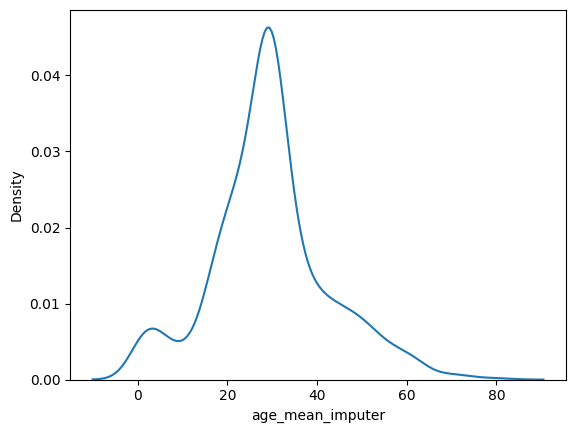

In [175]:
# Mean

sns.kdeplot(
    data=X_train,
    x='age_mean_imputer'
)

<Axes: xlabel='age_median_imputer', ylabel='Density'>

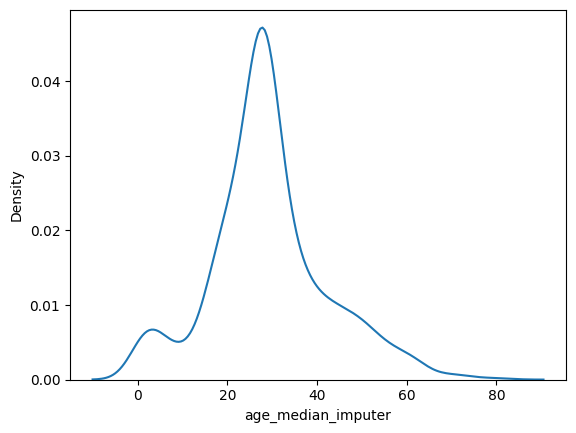

In [176]:
# Median

sns.kdeplot(
    data=X_train,
    x='age_median_imputer'
)

### Numerical Missing Values Imputation using Simple Imputer


In [177]:
from sklearn.impute import SimpleImputer

In [178]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(X_train[["Age"]])

X_train['Age'] = age_imputer.transform(X_train[["Age"]]).ravel()

In [179]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2
age_mean_imputer,0
age_median_imputer,0


In [180]:
X_train.drop(['age_median_imputer', 'age_mean_imputer'], inplace=True, axis=1)

In [181]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])
X_test.isnull().sum()
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputer,age_median_imputer
709,third,male,29.498846,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.000000,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.000000,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.000000,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.000000,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,29.498846,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.000000,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.000000,0,0,10.5000,NaN,S,17.000000,17.0


In [182]:
X_test.drop(['age_mean_imputer', 'age_median_imputer'], axis=1, inplace=True)

In [183]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


### Categorical Value Imputation with Mode Value

In [184]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])

# Transform both train and test data

X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel() # 2D ---> 1D
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel() # 2D ---> 1D

In [185]:
X_train.isnull().sum()
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0


### Categorical Value Imputation with Missing string and Indicator

<Axes: xlabel='Cabin', ylabel='count'>

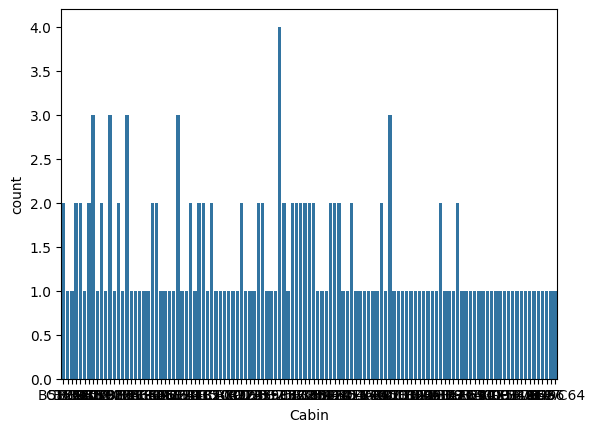

In [186]:
sns.countplot(data=X_train, x='Cabin')

In [187]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)
cabin_imputer.fit(X_train[['Cabin']])

# Transform both train and test data

X_train[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin', 'cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

In [188]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False
